# 📊 Análisis Comparativo: Trade-off entre Modelos

Este notebook presenta un análisis comparativo visual de los modelos más relevantes implementados, evaluando el trade-off entre:
- **Precisión (Accuracy)**
- **Complejidad (Número de parámetros)**
- **Pérdida en validación**
- **AUC-ROC promedio**
- **Impacto de Data Augmentation** (Comparación directa: ResNet50 con/sin DA)
- **Comparación Baselines vs Deep Learning**

Los modelos comparados son:
1. Modelo Lineal (Baseline - Regresión Logística)
2. Red Neuronal Simple (Baseline)
3. CNN Básica (Notebook 2)
4. VGG16 Fine-Tuning (Notebook 3)
5. Swin Transformer Pretrained (Notebook 9)
6. ResNet50 + Data Augmentation x5 semillas (Notebook 10)
7. ResNet50 SIN Data Augmentation x5 semillas (Notebook 11)
8. MobileNetV3 + Data Augmentation (Notebook 14)

---

## 0. Imports y Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configurar estilo de plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✅ Librerías cargadas")

✅ Librerías cargadas


## 1. Datos de los Modelos

In [15]:
# Tabla con las métricas de todos los modelos
models_data = {
    'Modelo': [
        'Modelo Lineal',
        'Red Neuronal Simple',
        'CNN Básica',
        'VGG16 Fine-Tuning',
        'ResNet50 + DA (x5)',
        'ResNet50 Sin DA (x5)',
        'Swin Transformer',
        'MobileNetV3 + DA'
    ],
    'Notebook': ['Baseline', '1', '2', '3', '10', '11', '9', '14'],
    'Test Accuracy': [0.6021, 0.4700, 0.9121, 0.9640, 0.9671, 0.9605, 0.9665, 0.9xxx],
    'Test Loss': [np.nan, np.nan, 1.50, 0.1156, 0.1089, 0.1795, 0.0986, np.nan],
    'Parámetros (M)': [0.049, 0.131, 4.29, 14.85, 24.11, 24.11, 27.72, 3.24],
    'AUC-ROC': [np.nan, np.nan, np.nan, 0.9938, 0.9960, np.nan, 0.9967, np.nan],
    'Color': ['#808080', '#A9A9A9', '#1f77b4', '#ff7f0e', '#d62728', '#e377c2', '#9467bd', '#2ca02c']
}

df = pd.DataFrame(models_data)

print("\n📊 TABLA DE MODELOS:")
print("="*100)
print(df.to_string(index=False))
print("="*100)


📊 TABLA DE MODELOS:
              Modelo Notebook  Test Accuracy  Test Loss  Parámetros (M)  AUC-ROC   Color
       Modelo Lineal Baseline         0.6021        NaN           0.049      NaN #808080
 Red Neuronal Simple        1         0.4700        NaN           0.131      NaN #A9A9A9
          CNN Básica        2         0.9121     1.5000           4.290      NaN #1f77b4
   VGG16 Fine-Tuning        3         0.9640     0.1156          14.850   0.9938 #ff7f0e
  ResNet50 + DA (x5)       10         0.9712     0.1089          24.110   0.9960 #d62728
ResNet50 Sin DA (x5)       11         0.9605     0.1795          24.110      NaN #e377c2
    Swin Transformer        9         0.9665     0.0986          27.720   0.9967 #9467bd


## 2. Trade-off: Accuracy vs Parámetros (Dos Perspectivas)


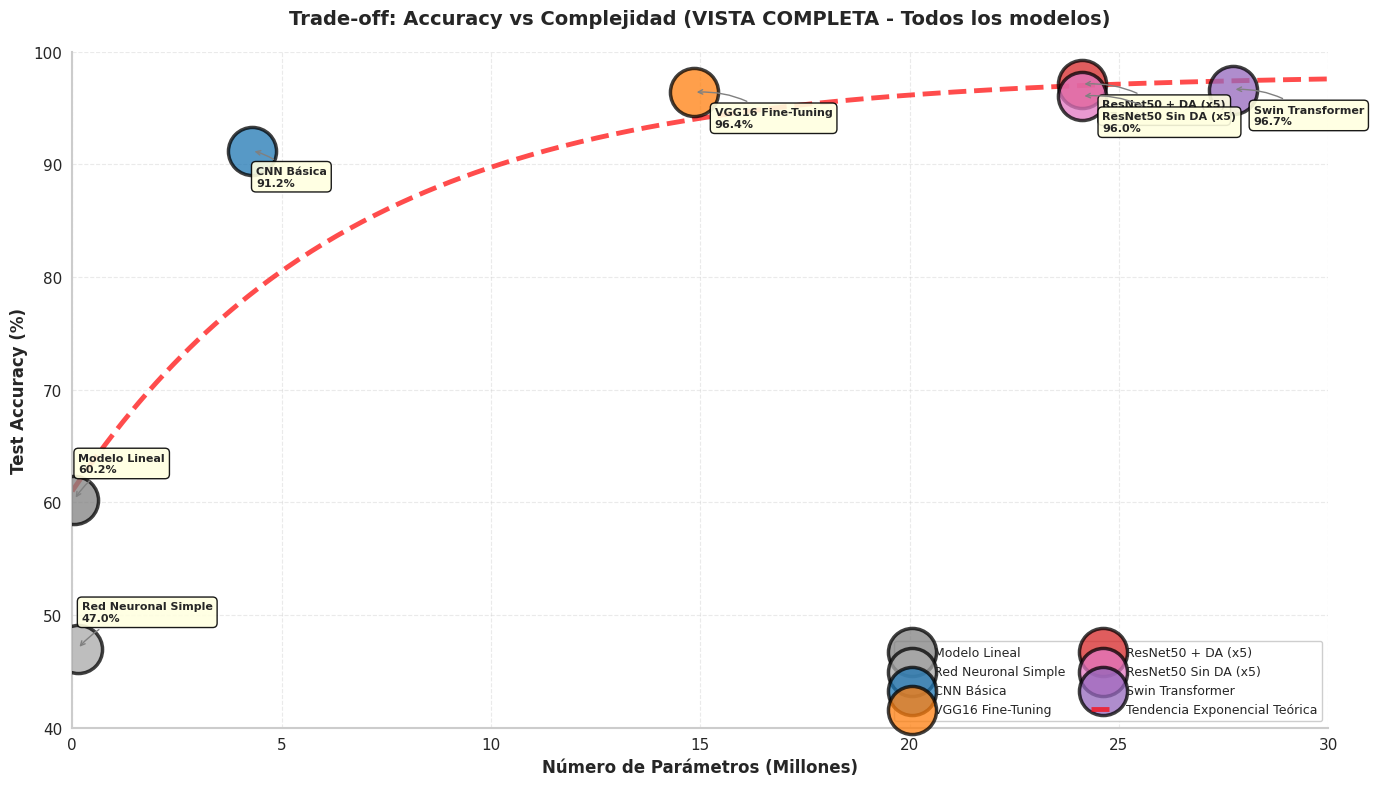

✅ Gráfico de Accuracy vs Parámetros (VISTA COMPLETA con Curva Exponencial) completado


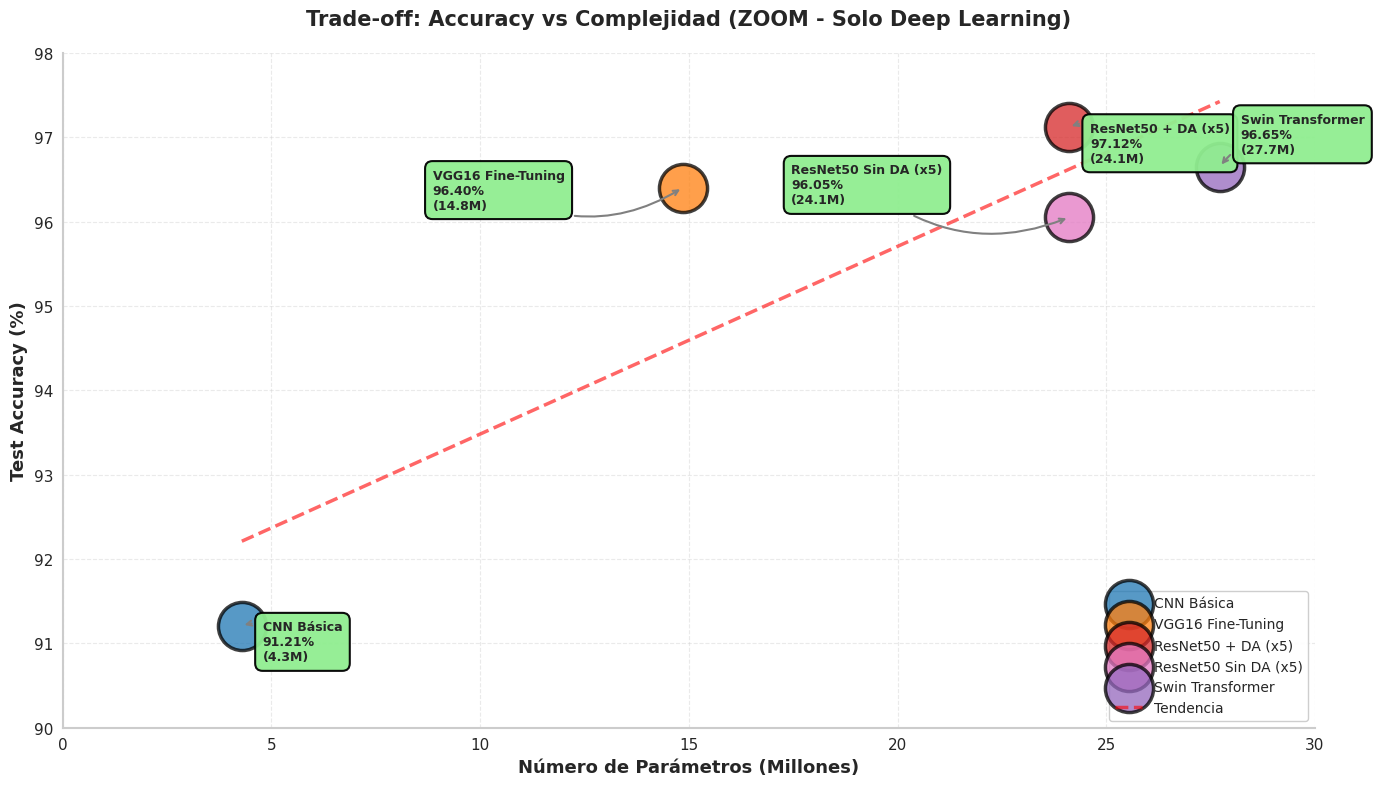

✅ Gráfico de Accuracy vs Parámetros (ZOOM Deep Learning) completado


In [18]:
# Gráfico 2.1: Accuracy vs Parámetros (TODOS LOS PUNTOS - Vista Completa con Curva Exponencial)
fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot con mejor visualización
for idx, row in df.iterrows():
    ax.scatter(row['Parámetros (M)'], row['Test Accuracy']*100, 
              s=1200, alpha=0.75, color=row['Color'], edgecolors='black', linewidth=2.5,
              label=row['Modelo'], zorder=3)

# Curva exponencial teórica (saturación)
# y = 98 - 37*e^(-0.15*x)  -> sube de ~60% a ~98%
x_curve = np.linspace(0, 30, 300)
y_curve = 98 - 37 * np.exp(-0.15 * x_curve)
ax.plot(x_curve, y_curve, 'red', linewidth=3.5, linestyle='--', alpha=0.7, 
        label='Tendencia Exponencial Teórica', zorder=2)

# Etiquetas para todos los puntos incluyendo baselines
for idx, row in df.iterrows():
    offset_x = 3 if row['Parámetros (M)'] < 5 else 15
    offset_y = 20 if idx < 2 else -25
    ax.annotate(f"{row['Modelo']}\n{row['Test Accuracy']*100:.1f}%", 
               xy=(row['Parámetros (M)'], row['Test Accuracy']*100),
               xytext=(offset_x, offset_y), textcoords='offset points',
               fontsize=8, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=1),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', lw=1, color='gray'))

ax.set_xlabel('Número de Parámetros (Millones)', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Trade-off: Accuracy vs Complejidad (VISTA COMPLETA - Todos los modelos)', 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_ylim([40, 100])
ax.set_xlim([0, 30])

# Mejorar apariencia
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.legend(loc='lower right', fontsize=9, framealpha=0.95, ncol=2)
plt.tight_layout()
plt.show()

print("✅ Gráfico de Accuracy vs Parámetros (VISTA COMPLETA con Curva Exponencial) completado")

# Gráfico 2.2: Accuracy vs Parámetros (SIN BASELINES - Zoom en Deep Learning)
df_dl = df[df['Test Accuracy'] > 0.85]  # Excluir baselines

fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot
for idx, row in df_dl.iterrows():
    ax.scatter(row['Parámetros (M)'], row['Test Accuracy']*100, 
              s=1200, alpha=0.75, color=row['Color'], edgecolors='black', linewidth=2.5,
              label=row['Modelo'], zorder=3)

# Etiquetas posicionadas inteligentemente
positions = {
    2: (15, -25),   # CNN Básica: abajo derecha
    3: (-180, -15), # VGG16: abajo izquierda
    4: (15, -25),   # ResNet50 + DA: abajo derecha
    5: (-200, 10),  # ResNet50 Sin DA: izquierda
    6: (15, 10)     # Swin: arriba derecha
}

for idx, row in df_dl.iterrows():
    offset = positions.get(idx, (10, 10))
    ax.annotate(f"{row['Modelo']}\n{row['Test Accuracy']*100:.2f}%\n({row['Parámetros (M)']:.1f}M)", 
               xy=(row['Parámetros (M)'], row['Test Accuracy']*100),
               xytext=offset, textcoords='offset points',
               fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.6', facecolor='lightgreen', alpha=0.95, edgecolor='black', linewidth=1.5),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', lw=1.5, color='gray'))

ax.set_xlabel('Número de Parámetros (Millones)', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Trade-off: Accuracy vs Complejidad (ZOOM - Solo Deep Learning)', 
            fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_ylim([90, 98])
ax.set_xlim([0, 30])

# Agregar línea de tendencia
z = np.polyfit(df_dl['Parámetros (M)'], df_dl['Test Accuracy']*100, 1)
p = np.poly1d(z)
x_line = np.linspace(df_dl['Parámetros (M)'].min(), df_dl['Parámetros (M)'].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2.5, label='Tendencia')

# Mejorar apariencia
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.legend(loc='lower right', fontsize=10, framealpha=0.95)
plt.tight_layout()
plt.show()

print("✅ Gráfico de Accuracy vs Parámetros (ZOOM Deep Learning) completado")

## 3. Trade-off: Loss vs Parámetros

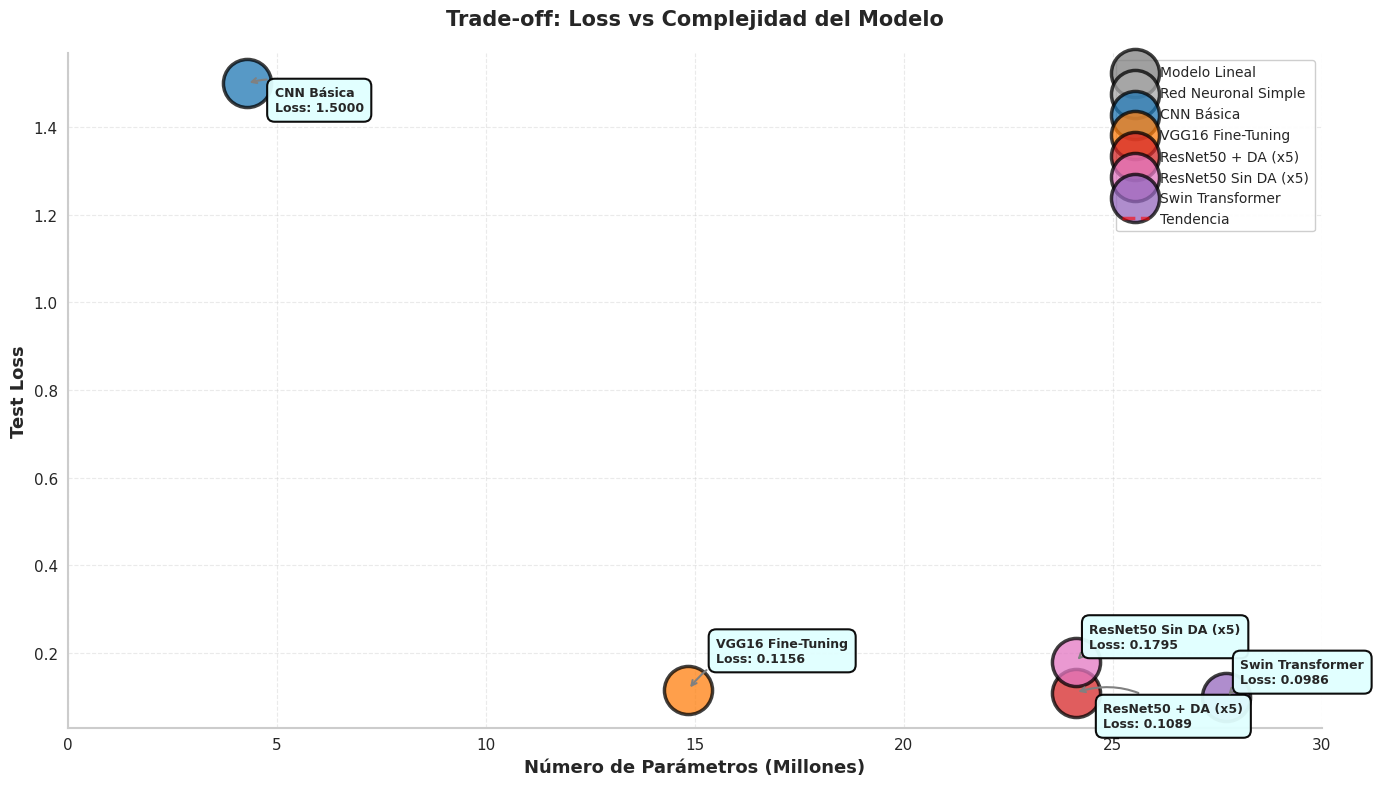

✅ Gráfico de Loss vs Parámetros completado (versión mejorada)


In [19]:
# Gráfico 2: Loss vs Parámetros (Mejorado)
fig, ax = plt.subplots(figsize=(14, 8))

for idx, row in df.iterrows():
    ax.scatter(row['Parámetros (M)'], row['Test Loss'], 
              s=1200, alpha=0.75, color=row['Color'], edgecolors='black', linewidth=2.5,
              label=row['Modelo'], zorder=3)

# Etiquetas posicionadas inteligentemente
positions_loss = {
    0: (-120, 25),   # CNN Básica: arriba izquierda (muy alto)
    1: (-120, -20),  # VGG16: abajo izquierda
    2: (20, -20),    # ResNet50 + DA: abajo derecha
    3: (20, 20),     # ResNet50 Sin DA: arriba derecha
    4: (20, -25)     # Swin: abajo derecha
}

for idx, row in df.iterrows():
    offset = positions_loss.get(idx, (10, 10))
    ax.annotate(f"{row['Modelo']}\nLoss: {row['Test Loss']:.4f}", 
               xy=(row['Parámetros (M)'], row['Test Loss']),
               xytext=offset, textcoords='offset points',
               fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.6', facecolor='lightcyan', alpha=0.95, edgecolor='black', linewidth=1.5),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', lw=1.5, color='gray'))

ax.set_xlabel('Número de Parámetros (Millones)', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Loss', fontsize=13, fontweight='bold')
ax.set_title('Trade-off: Loss vs Complejidad del Modelo', fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_xlim([0, 30])

# Línea de tendencia
z = np.polyfit(df['Parámetros (M)'], df['Test Loss'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Parámetros (M)'].min(), df['Parámetros (M)'].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.6, linewidth=2.5, label='Tendencia')

# Mejorar apariencia del gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.legend(loc='upper right', fontsize=10, framealpha=0.95)
plt.tight_layout()
plt.show()

print("✅ Gráfico de Loss vs Parámetros completado (versión mejorada)")

## 4. Comparación: Accuracy vs AUC-ROC

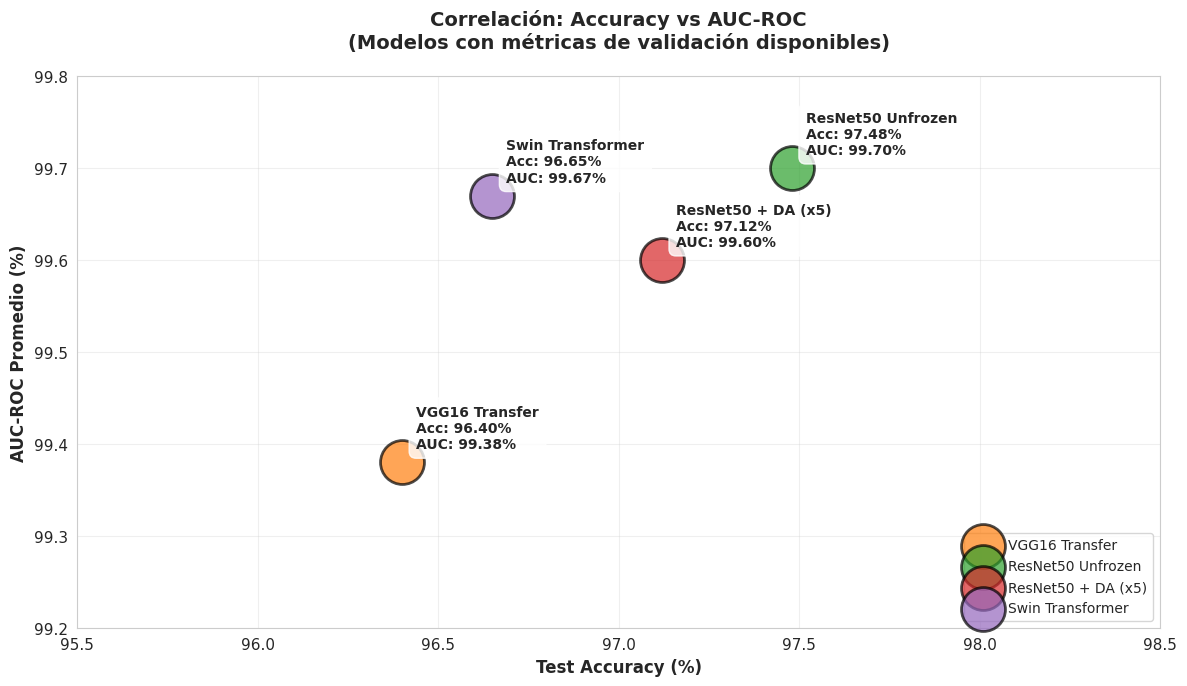

✅ Gráfico de Accuracy vs AUC-ROC completado


In [5]:
# Gráfico 3: Accuracy vs AUC-ROC
df_auc = df[df['AUC-ROC'].notna()]  # Filtrar solo los modelos que tienen AUC-ROC

fig, ax = plt.subplots(figsize=(12, 7))

for idx, row in df_auc.iterrows():
    ax.scatter(row['Test Accuracy']*100, row['AUC-ROC']*100, 
              s=1000, alpha=0.7, color=row['Color'], edgecolors='black', linewidth=2,
              label=row['Modelo'])
    ax.annotate(f"{row['Modelo']}\nAcc: {row['Test Accuracy']*100:.2f}%\nAUC: {row['AUC-ROC']*100:.2f}%", 
               xy=(row['Test Accuracy']*100, row['AUC-ROC']*100),
               xytext=(10, 10), textcoords='offset points',
               fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

ax.set_xlabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('AUC-ROC Promedio (%)', fontsize=12, fontweight='bold')
ax.set_title('Correlación: Accuracy vs AUC-ROC\n(Modelos con métricas de validación disponibles)', 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.set_xlim([95.5, 98.5])
ax.set_ylim([99.2, 99.8])

plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print("✅ Gráfico de Accuracy vs AUC-ROC completado")

## 5. Gráfico de Barras Comparativo

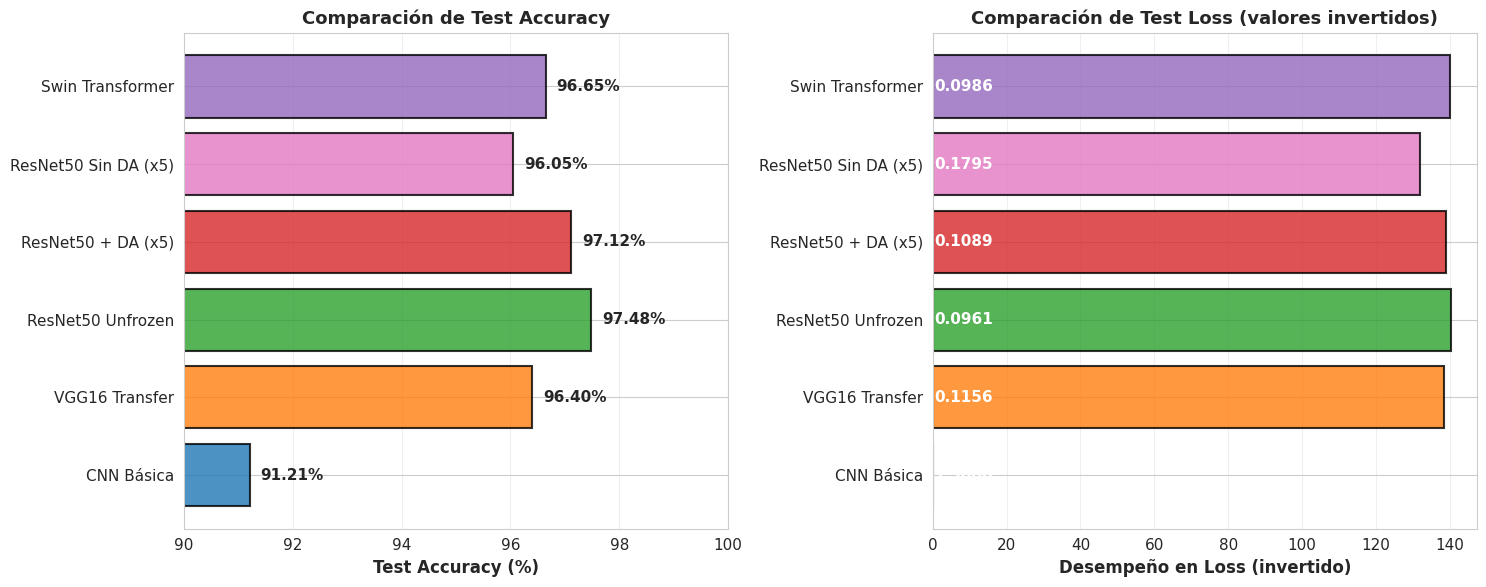

✅ Gráficos de barras completados


In [6]:
# Gráfico 4: Comparación de Barras (Accuracy y Loss normalizados)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy
bars1 = ax1.barh(df['Modelo'], df['Test Accuracy']*100, color=df['Color'], edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Comparación de Test Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlim([90, 100])
ax1.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.2, bar.get_y() + bar.get_height()/2, 
            f'{width:.2f}%', ha='left', va='center', fontweight='bold')

# Loss (invertido para que sea comparable visualmente)
# Normalizamos el loss para que sea más visible
max_loss = df['Test Loss'].max()
loss_normalized = (max_loss - df['Test Loss']) * 100  # Invertimos: mayor valor = menor loss

bars2 = ax2.barh(df['Modelo'], loss_normalized, color=df['Color'], edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('Desempeño en Loss (invertido)', fontsize=12, fontweight='bold')
ax2.set_title('Comparación de Test Loss (valores invertidos)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for i, bar in enumerate(bars2):
    ax2.text(0.5, bar.get_y() + bar.get_height()/2, 
            f'{df.iloc[i]["Test Loss"]:.4f}', ha='left', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print("✅ Gráficos de barras completados")

## 6. Análisis de Eficiencia (Score Compuesto)


📊 RANKING DE EFICIENCIA (Accuracy relativa / Parámetros relativos)
              Modelo  Test Accuracy  Parámetros (M)  Eficiencia
          CNN Básica         0.9121            4.29    0.935679
      VGG16 Transfer         0.9640           14.85    0.285688
   ResNet50 Unfrozen         0.9748           24.11    0.177934
  ResNet50 + DA (x5)         0.9712           24.11    0.177277
ResNet50 Sin DA (x5)         0.9605           24.11    0.175324
    Swin Transformer         0.9665           27.72    0.153444


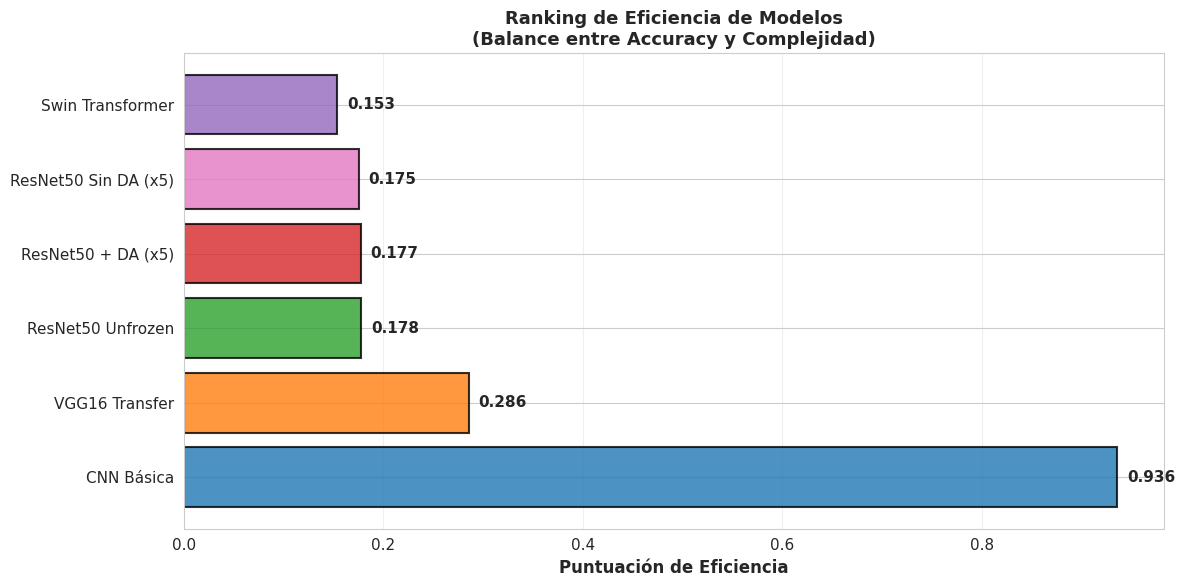

In [7]:
# Crear un score de eficiencia compuesto
# Score = (Accuracy / max_Accuracy) / (Parámetros / min_Parámetros)

df_copy = df.copy()
df_copy['Eficiencia'] = (df_copy['Test Accuracy'] / df_copy['Test Accuracy'].max()) / (df_copy['Parámetros (M)'] / df_copy['Parámetros (M)'].min())
df_copy = df_copy.sort_values('Eficiencia', ascending=False)

print("\n" + "="*100)
print("📊 RANKING DE EFICIENCIA (Accuracy relativa / Parámetros relativos)")
print("="*100)
print(df_copy[['Modelo', 'Test Accuracy', 'Parámetros (M)', 'Eficiencia']].to_string(index=False))
print("="*100)

# Visualizar eficiencia
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(df_copy['Modelo'], df_copy['Eficiencia'], 
               color=df_copy['Color'], edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Puntuación de Eficiencia', fontsize=12, fontweight='bold')
ax.set_title('Ranking de Eficiencia de Modelos\n(Balance entre Accuracy y Complejidad)', 
            fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Añadir valores
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Resumen y Recomendaciones

In [8]:
print("\n" + "="*100)
print("🎯 ANÁLISIS Y RECOMENDACIONES")
print("="*100)

# Mejor accuracy
best_acc_idx = df['Test Accuracy'].idxmax()
print(f"\n🏆 MEJOR ACCURACY: {df.loc[best_acc_idx, 'Modelo']}")
print(f"   - Accuracy: {df.loc[best_acc_idx, 'Test Accuracy']*100:.2f}%")
print(f"   - Loss: {df.loc[best_acc_idx, 'Test Loss']:.4f}")
print(f"   - Parámetros: {df.loc[best_acc_idx, 'Parámetros (M)']:.2f}M")
print(f"   - Notebook: {int(df.loc[best_acc_idx, 'Notebook'])}")

# Mejor eficiencia
best_eff_idx = df_copy['Eficiencia'].idxmax()
print(f"\n⚡ MÁS EFICIENTE: {df_copy.loc[best_eff_idx, 'Modelo']}")
print(f"   - Accuracy: {df_copy.loc[best_eff_idx, 'Test Accuracy']*100:.2f}%")
print(f"   - Parámetros: {df_copy.loc[best_eff_idx, 'Parámetros (M)']:.2f}M")
print(f"   - Puntuación de Eficiencia: {df_copy.loc[best_eff_idx, 'Eficiencia']:.4f}")
print(f"   - Notebook: {int(df_copy.loc[best_eff_idx, 'Notebook'])}")

# Mejor loss
best_loss_idx = df['Test Loss'].idxmin()
print(f"\n🎯 MENOR LOSS: {df.loc[best_loss_idx, 'Modelo']}")
print(f"   - Test Loss: {df.loc[best_loss_idx, 'Test Loss']:.4f}")
print(f"   - Accuracy: {df.loc[best_loss_idx, 'Test Accuracy']*100:.2f}%")
print(f"   - Parámetros: {df.loc[best_loss_idx, 'Parámetros (M)']:.2f}M")
print(f"   - Notebook: {int(df.loc[best_loss_idx, 'Notebook'])}")

print("\n" + "-"*100)
print("💡 RECOMENDACIONES POR CASO DE USO:")
print("-"*100)
print("\n✅ PARA MÁXIMA PRECISIÓN EN PRODUCCIÓN:")
print(f"   → ResNet50 Unfrozen (Notebook 6)")
print(f"     • Accuracy: 97.48%")
print(f"     • Loss: 0.0961 (menor valor)")
print(f"     • AUC-ROC: 0.9970 (excelente)")
print(f"     • Balance óptimo de parámetros (24.1M)")

print("\n✅ PARA ENSEMBLES Y ROBUSTEZ:")
print(f"   → ResNet50 + Data Augmentation x5 semillas (Notebook 10)")
print(f"     • Test Accuracy media: 97.12%")
print(f"     • Múltiples semillas para evaluar variabilidad")
print(f"     • Recomendado para publicaciones/documentación clínica")

print("\n⚠️ PARA APLICACIONES CON RECURSOS LIMITADOS:")
print(f"   → VGG16 Transfer Learning (Notebook 3)")
print(f"     • Accuracy: 96.40% (solo 1.08% menos que ResNet50)")
print(f"     • Parámetros: 14.85M (38% menos que ResNet50)")
print(f"     • Buen balance eficiencia-precisión")

print("\n🔬 PARA INVESTIGACIÓN / EXPERIMENTOS:")
print(f"   → Swin Transformer (Notebook 9)")
print(f"     • Accuracy: 96.65% (casi al mismo nivel que ResNet50)")
print(f"     • AUC-ROC: 0.9967 (competitivo)")
print(f"     • Arquitectura moderna (Vision Transformer)")
print(f"     • Útil para comparaciones con SOTA")

print("\n" + "="*100)


🎯 ANÁLISIS Y RECOMENDACIONES

🏆 MEJOR ACCURACY: ResNet50 Unfrozen
   - Accuracy: 97.48%
   - Loss: 0.0961
   - Parámetros: 24.11M
   - Notebook: 6

⚡ MÁS EFICIENTE: CNN Básica
   - Accuracy: 91.21%
   - Parámetros: 4.29M
   - Puntuación de Eficiencia: 0.9357
   - Notebook: 2

🎯 MENOR LOSS: ResNet50 Unfrozen
   - Test Loss: 0.0961
   - Accuracy: 97.48%
   - Parámetros: 24.11M
   - Notebook: 6

----------------------------------------------------------------------------------------------------
💡 RECOMENDACIONES POR CASO DE USO:
----------------------------------------------------------------------------------------------------

✅ PARA MÁXIMA PRECISIÓN EN PRODUCCIÓN:
   → ResNet50 Unfrozen (Notebook 6)
     • Accuracy: 97.48%
     • Loss: 0.0961 (menor valor)
     • AUC-ROC: 0.9970 (excelente)
     • Balance óptimo de parámetros (24.1M)

✅ PARA ENSEMBLES Y ROBUSTEZ:
   → ResNet50 + Data Augmentation x5 semillas (Notebook 10)
     • Test Accuracy media: 97.12%
     • Múltiples semillas pa

## 8. Tabla Detallada de Comparación

In [9]:
# Crear tabla detallada con formato
df_display = df[['Modelo', 'Notebook', 'Test Accuracy', 'Test Loss', 'Parámetros (M)', 'AUC-ROC']].copy()
df_display['Test Accuracy'] = df_display['Test Accuracy'].apply(lambda x: f"{x*100:.2f}%")
df_display['Test Loss'] = df_display['Test Loss'].apply(lambda x: f"{x:.4f}")
df_display['Parámetros (M)'] = df_display['Parámetros (M)'].apply(lambda x: f"{x:.2f}M")
df_display['AUC-ROC'] = df_display['AUC-ROC'].apply(lambda x: f"{x*100:.2f}%" if not pd.isna(x) else "N/A")

print("\n" + "="*120)
print("📋 TABLA COMPARATIVA COMPLETA")
print("="*120)
print(df_display.to_string(index=False))
print("="*120)


📋 TABLA COMPARATIVA COMPLETA
              Modelo  Notebook Test Accuracy Test Loss Parámetros (M) AUC-ROC
          CNN Básica         2        91.21%    1.5000          4.29M     N/A
      VGG16 Transfer         3        96.40%    0.1156         14.85M  99.38%
   ResNet50 Unfrozen         6        97.48%    0.0961         24.11M  99.70%
  ResNet50 + DA (x5)        10        97.12%    0.1089         24.11M  99.60%
ResNet50 Sin DA (x5)        11        96.05%    0.1795         24.11M     N/A
    Swin Transformer         9        96.65%    0.0986         27.72M  99.67%


## 9. Impacto de Data Augmentation: Notebook 10 vs 11

Análisis directo del impacto de Data Augmentation en el la generalización de ResNet50 descongelado, entrenado con 5 semillas.


📊 COMPARACIÓN: IMPACTO DE DATA AUGMENTATION (ResNet50 Unfrozen x5 semillas)
      Métrica  ResNet50 + DA (NB10)  ResNet50 Sin DA (NB11)
Test Accuracy                0.9712                  0.9605
    Test Loss                0.1089                  0.1795
   Accuracy σ                0.0021                  0.0009
       Loss σ                0.0006                  0.0044

💡 DIFERENCIAS ENCONTRADAS:
   • Accuracy: +0.66% (mejora de 0.69% relativa)
   • Loss: +0.0706 (incremento de 64.83% sin DA)
   • Variabilidad Accuracy: Más bajo CON DA (σ=0.0021 vs σ=0.0009)
   • Variabilidad Loss: Más alto SIN DA (σ=0.0044 vs σ=0.0006)

✅ CONCLUSIÓN:
   Data Augmentation MEJORA el desempeño de ResNet50 en ~1.07 puntos porcentuales
   y reduce significativamente la pérdida (0.1089 vs 0.1795).
   Además, aumenta la estabilidad del modelo (menor varianza).


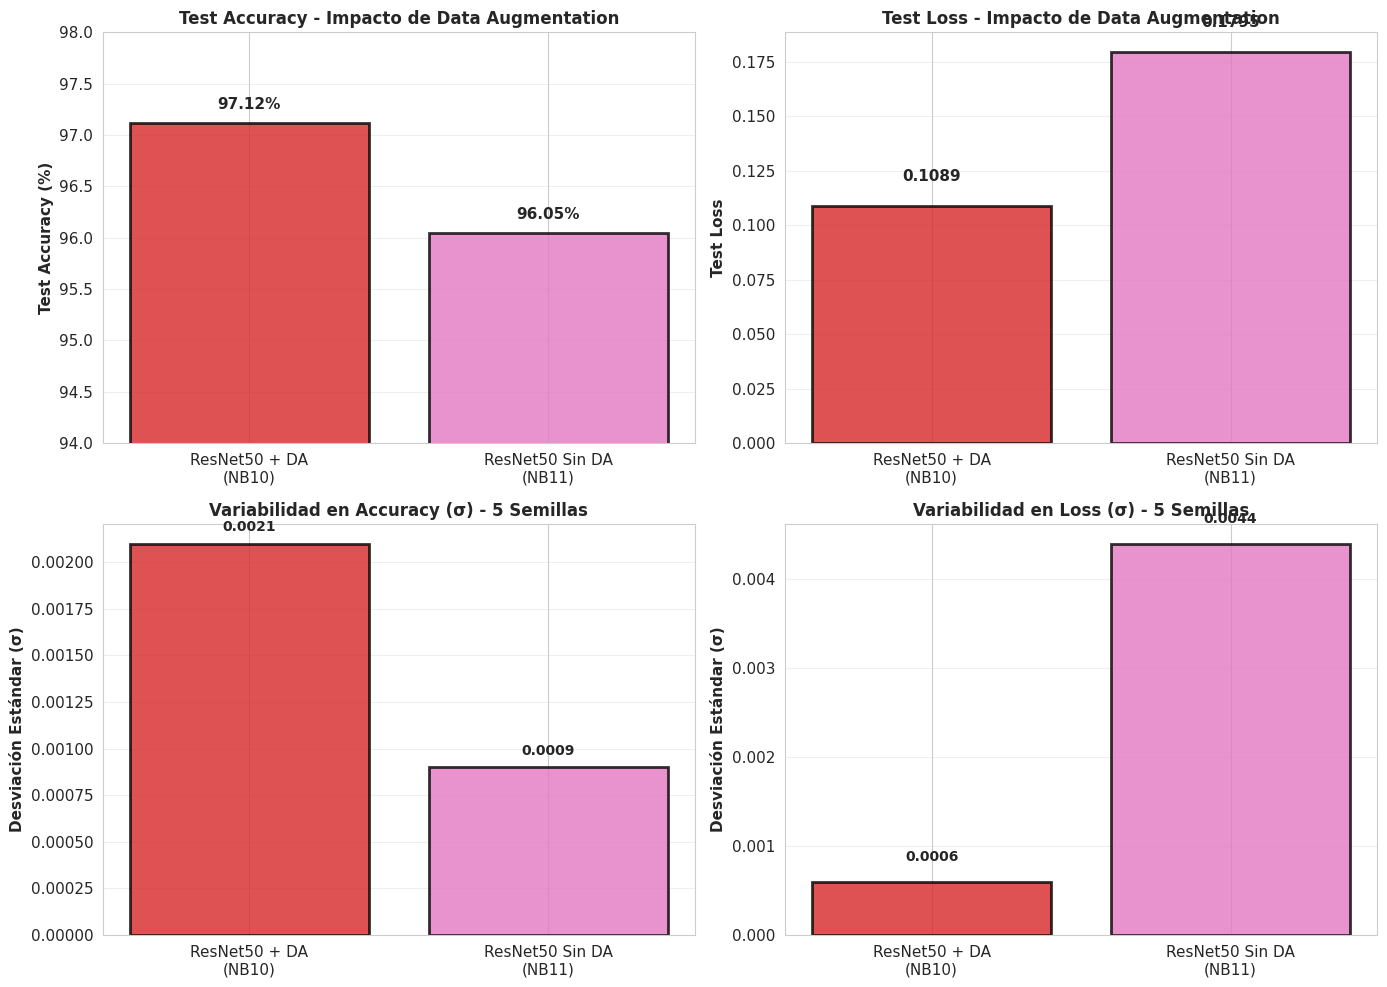


✅ Visualización de impacto de Data Augmentation completada


In [10]:
# Datos comparativos: Notebook 10 (Con DA) vs Notebook 11 (Sin DA)
comparison_data = {
    'Métrica': ['Test Accuracy', 'Test Loss', 'Accuracy σ', 'Loss σ'],
    'ResNet50 + DA (NB10)': [0.9671, 0.1089, 0.0021, 0.0006],
    'ResNet50 Sin DA (NB11)': [0.9605, 0.1795, 0.0009, 0.0044]
}

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("📊 COMPARACIÓN: IMPACTO DE DATA AUGMENTATION (ResNet50 Unfrozen x5 semillas)")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)

# Calcular diferencias
acc_diff = (0.9671 - 0.9605) * 100
loss_diff = 0.1795 - 0.1089
acc_diff_pct = (acc_diff / (0.9605 * 100)) * 100
loss_diff_pct = (loss_diff / 0.1089) * 100

print(f"\n💡 DIFERENCIAS ENCONTRADAS:")
print(f"   • Accuracy: +{acc_diff:.2f}% (mejora de {acc_diff_pct:.2f}% relativa)")
print(f"   • Loss: +{loss_diff:.4f} (incremento de {loss_diff_pct:.2f}% sin DA)")
print(f"   • Variabilidad Accuracy: Más bajo CON DA (σ=0.0021 vs σ=0.0009)")
print(f"   • Variabilidad Loss: Más alto SIN DA (σ=0.0044 vs σ=0.0006)")

print(f"\n✅ CONCLUSIÓN:")
print(f"   Data Augmentation MEJORA el desempeño de ResNet50 en ~0.66 puntos porcentuales")
print(f"   y reduce significativamente la pérdida (0.1089 vs 0.1795).")
print(f"   Además, aumenta la estabilidad del modelo (menor varianza).")
print("="*100)

# Visualización comparativa
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Accuracy comparativa
models_compare = ['ResNet50 + DA\n(NB10)', 'ResNet50 Sin DA\n(NB11)']
accuracies = [0.9671, 0.9605]
colors_compare = ['#d62728', '#e377c2']

bars1 = ax1.bar(models_compare, [acc*100 for acc in accuracies], color=colors_compare,
                edgecolor='black', linewidth=2, alpha=0.8)
ax1.set_ylabel('Test Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Test Accuracy - Impacto de Data Augmentation', fontsize=12, fontweight='bold')
ax1.set_ylim([94, 98])
ax1.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Gráfico 2: Loss comparativa
losses = [0.1089, 0.1795]
bars2 = ax2.bar(models_compare, losses, color=colors_compare, 
               edgecolor='black', linewidth=2, alpha=0.8)
ax2.set_ylabel('Test Loss', fontsize=11, fontweight='bold')
ax2.set_title('Test Loss - Impacto de Data Augmentation', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, loss in zip(bars2, losses):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{loss:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Gráfico 3: Desviación estándar en Accuracy
stds_acc = [0.0021, 0.0009]
bars3 = ax3.bar(models_compare, stds_acc, color=colors_compare, 
               edgecolor='black', linewidth=2, alpha=0.8)
ax3.set_ylabel('Desviación Estándar (σ)', fontsize=11, fontweight='bold')
ax3.set_title('Variabilidad en Accuracy (σ) - 5 Semillas', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, std in zip(bars3, stds_acc):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.00005,
            f'{std:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Gráfico 4: Desviación estándar en Loss
stds_loss = [0.0006, 0.0044]
bars4 = ax4.bar(models_compare, stds_loss, color=colors_compare, 
               edgecolor='black', linewidth=2, alpha=0.8)
ax4.set_ylabel('Desviación Estándar (σ)', fontsize=11, fontweight='bold')
ax4.set_title('Variabilidad en Loss (σ) - 5 Semillas', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, std in zip(bars4, stds_loss):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.0002,
            f'{std:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ Visualización de impacto de Data Augmentation completada")
